# Transfer Learning con PyTorch

Entrenar CNNs desde cero requiere grandes cantidades de datos y tiempo de cómputo. Gran parte de ese esfuerzo se invierte en aprender filtros de bajo nivel que son útiles para cualquier tarea de visión. Surge entonces una pregunta natural: ¿podemos reutilizar una red entrenada en un dataset y adaptarla a una tarea diferente sin repetir el proceso completo?

Eso es precisamente **transfer learning**: transferimos el conocimiento de un modelo preentrenado (generalmente en **ImageNet**) a nuestra tarea específica. Las capas convolucionales ya saben extraer bordes, texturas y formas genéricas; nosotros solo necesitamos adaptar la cabeza de clasificación.

En este notebook exploraremos tres estrategias:
1. Extracción de features con el backbone congelado
2. Reemplazar el clasificador final y entrenar solo esa parte
3. Fine-tuning: descongelar gradualmente el backbone


## 0. Imports y configuración


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torchinfo import summary
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image
import glob

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Usando device: {device}')


2026-03-22 16:30:12.162071: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774197012.371053      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774197012.436740      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774197012.915602      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774197012.915639      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774197012.915642      55 computation_placer.cc:177] computation placer alr

Usando device: cuda


## 1. Funciones auxiliares

Definimos aquí las utilidades que usaremos a lo largo del notebook: verificación del dataset, visualización de muestras, y el loop de entrenamiento con logging a TensorBoard.


In [2]:
def check_image_dir(pattern):
    """Elimina imágenes corruptas que coincidan con el patrón glob."""
    removed = 0
    for fname in glob.glob(pattern):
        try:
            img = Image.open(fname)
            img.verify()
        except Exception:
            print(f'Eliminando archivo corrupto: {fname}')
            os.remove(fname)
            removed += 1
    print(f'{pattern}: {removed} archivos eliminados')


def display_dataset(dataset, n=10):
    """Muestra n imágenes aleatorias del dataset con su etiqueta."""
    indices = np.random.choice(len(dataset), n, replace=False)
    fig, axes = plt.subplots(2, n // 2, figsize=(15, 5))
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    for ax, idx in zip(axes.flat, indices):
        img, label = dataset[idx]
        img = (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
        ax.imshow(img)
        title = dataset.classes[label] if hasattr(dataset, 'classes') else str(label)
        ax.set_title(title, fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


def train_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(X)
        loss = loss_fn(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct += (out.argmax(1) == y).sum().item()
        total += len(y)
    return total_loss / total, correct / total


def eval_epoch(model, loader, loss_fn):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            loss = loss_fn(out, y)
            total_loss += loss.item() * len(y)
            correct += (out.argmax(1) == y).sum().item()
            total += len(y)
    return total_loss / total, correct / total


def train(
    model, train_loader, test_loader,
    loss_fn=None, optimizer=None,
    epochs=5, lr=1e-3, writer=None, tag=''
):
    if loss_fn is None:
        loss_fn = nn.CrossEntropyLoss()
    if optimizer is None:
        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()), lr=lr
        )
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, loss_fn)
        va_loss, va_acc = eval_epoch(model, test_loader, loss_fn)
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)
        if writer:
            writer.add_scalars(f'{tag}/Loss', {'train': tr_loss, 'val': va_loss}, epoch)
            writer.add_scalars(f'{tag}/Acc',  {'train': tr_acc,  'val': va_acc},  epoch)
        print(f'Epoch {epoch:02d}/{epochs} | '
              f'train loss {tr_loss:.4f} acc {tr_acc:.4f} | '
              f'val loss {va_loss:.4f} acc {va_acc:.4f}')
    return history


def plot_results(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history['train_loss'], label='train')
    ax1.plot(history['val_loss'],   label='val')
    ax1.set_title('Loss'); ax1.legend()
    ax2.plot(history['train_acc'], label='train')
    ax2.plot(history['val_acc'],   label='val')
    ax2.set_title('Accuracy'); ax2.legend()
    plt.tight_layout()
    plt.show()

print('Funciones auxiliares definidas ✓')


Funciones auxiliares definidas ✓


## 2. Dataset: Cats vs. Dogs

Usaremos el [Kaggle Cats vs. Dogs Dataset](https://www.kaggle.com/c/dogs-vs-cats), también disponible [desde Microsoft](https://www.microsoft.com/en-us/download/details.aspx?id=54765). Es un conjunto clásico de ~25 000 imágenes de gatos y perros, ideal para experimentar con transfer learning porque el dominio (fotografías naturales) coincide con ImageNet.


In [3]:
import zipfile

os.makedirs('data', exist_ok=True)

if not os.path.exists('data/kagglecatsanddogs_5340.zip'):
    !wget -P data https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip

if not os.path.exists('data/PetImages'):
    with zipfile.ZipFile('data/kagglecatsanddogs_5340.zip', 'r') as zip_ref:
        zip_ref.extractall('data')


--2026-03-22 16:30:35--  https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip
Resolving download.microsoft.com (download.microsoft.com)... 184.31.114.62, 2600:1407:7400:1187::317f, 2600:1407:7400:1184::317f
Connecting to download.microsoft.com (download.microsoft.com)|184.31.114.62|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 824887076 (787M) [application/octet-stream]
Saving to: ‘data/kagglecatsanddogs_5340.zip’

kagglecatsanddogs_5 100%[===================>] 786.67M   124MB/s    in 6.3s    

2026-03-22 16:30:42 (124 MB/s) - ‘data/kagglecatsanddogs_5340.zip’ saved [824887076/824887076]



El dataset contiene algunas imágenes corruptas. Las eliminamos antes de construir el `Dataset`:


In [4]:
check_image_dir('data/PetImages/Cat/*.jpg')
check_image_dir('data/PetImages/Dog/*.jpg')


Eliminando archivo corrupto: data/PetImages/Cat/666.jpg
data/PetImages/Cat/*.jpg: 1 archivos eliminados


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Eliminando archivo corrupto: data/PetImages/Dog/11702.jpg
data/PetImages/Dog/*.jpg: 1 archivos eliminados


### Transforms y normalización

Los modelos preentrenados en ImageNet esperan imágenes de **224 × 224** píxeles normalizadas con la media y desviación estándar del dataset de entrenamiento original:

```
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]
```

Usar estos valores es fundamental: si los activamos con distribuciones de entrada distintas, los pesos preentrenados producirán representaciones incorrectas.

> **TODO 1:** Completa el pipeline de transforms. Debe redimensionar a 256, recortar al centro 224 × 224, convertir a tensor y aplicar la normalización.


Total de imágenes: 24998 | Clases: ['Cat', 'Dog']
Train: 20000 | Test: 4998


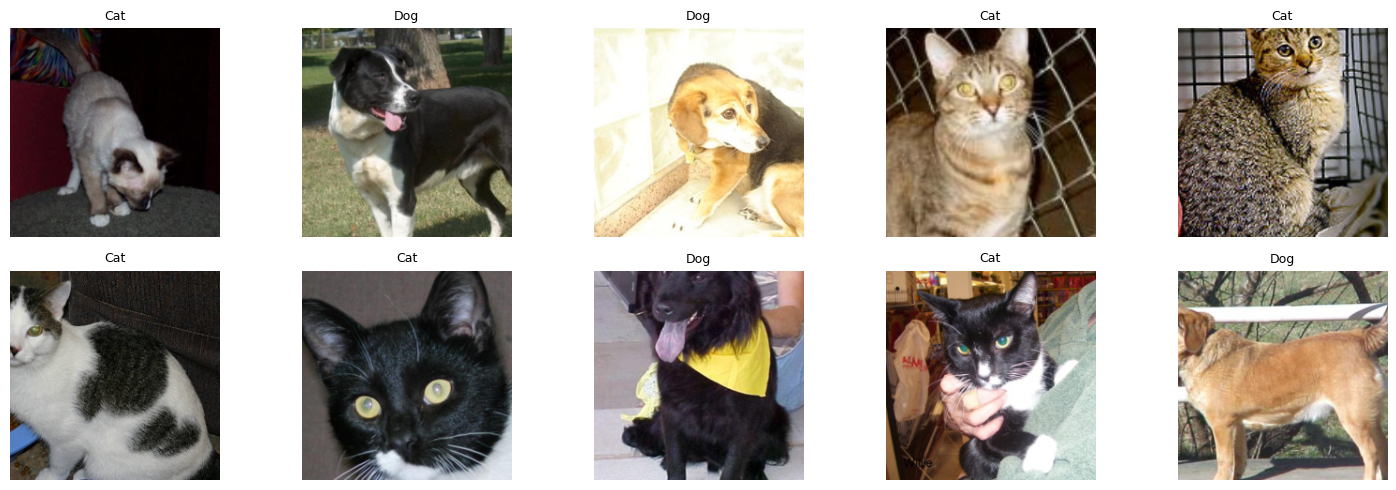

In [5]:
std_normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std =[0.229, 0.224, 0.225]
)

# TODO 1: Define `trans` como un transforms.Compose con los pasos indicados arriba
trans = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    std_normalize
])

# --- no modificar desde aquí ---
assert trans is not None, 'Debes definir el pipeline de transforms'
dataset = torchvision.datasets.ImageFolder('data/PetImages', transform=trans)
print(f'Total de imágenes: {len(dataset)} | Clases: {dataset.classes}')

trainset, testset = torch.utils.data.random_split(
    dataset, [20000, len(dataset) - 20000],
    generator=torch.Generator().manual_seed(42)
)
print(f'Train: {len(trainset)} | Test: {len(testset)}')
display_dataset(dataset)


### Respuesta — Actividad 1

**Pregunta:** ¿De dónde vienen esos valores de media y std? ¿Por qué es importante usarlos si vas a cargar pesos preentrenados?

**Origen de mean/std de ImageNet:** Se calcularon por canal (R, G, B) sobre aproximadamente 1.2 millones de imágenes del training set original de ImageNet (ILSVRC 2012).

**Importancia:** Los pesos preentrenados (filtros convolucionales) asumen estrictamente esta distribución de entrada. Proveer valores con escalas diferentes produce activaciones numéricamente incorrectas y causa que los filtros no se activen como se espera, degradando fuertemente el desempeño del transfer learning.


## 3. Modelos preentrenados

`torchvision.models` incluye decenas de arquitecturas con pesos preentrenados en ImageNet. Cargamos VGG-16 y lo usamos directamente para hacer una inferencia sobre una imagen del dataset:


In [6]:
vgg = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.DEFAULT)
vgg = vgg.to(device)

sample_image, _ = dataset[0]
sample_image = sample_image.unsqueeze(0).to(device)

with torch.no_grad():
    res = vgg(sample_image)

print(f'Shape de salida: {res.shape}')  # [1, 1000]
print(f'Clase predicha (índice ImageNet): {res[0].argmax().item()}')


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 234MB/s]  


Shape de salida: torch.Size([1, 1000])
Clase predicha (índice ImageNet): 281


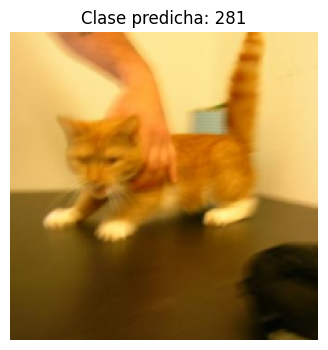

In [7]:
# Visualizar la imagen
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

img_show = (sample_image.squeeze(0).cpu() * std + mean).clamp(0, 1)
img_show = img_show.permute(1, 2, 0).numpy()

plt.figure(figsize=(4, 4))
plt.imshow(img_show)
plt.title(f'Clase predicha: {res[0].argmax().item()}')
plt.axis('off')
plt.show()

La red devuelve un índice de clase de ImageNet. Podemos descargar el mapeo para ver el nombre de la predicción:


In [8]:
import json, requests

class_map = json.loads(
    requests.get('https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json').text
)
class_map = {int(k): v for k, v in class_map.items()}

pred_idx = res[0].argmax().item()
print(f'Clase predicha: {class_map[pred_idx]}')


Clase predicha: ['n02123045', 'tabby']


### Arquitectura de VGG-16

Inspeccionemos la arquitectura completa con `torchinfo.summary`. Fíjate en el número total de parámetros y en los tipos de capas que aparecen:


In [9]:
summary(vgg, input_size=(1, 3, 224, 224))


Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      [1, 1000]                 --
├─Sequential: 1-1                        [1, 512, 7, 7]            --
│    └─Conv2d: 2-1                       [1, 64, 224, 224]         1,792
│    └─ReLU: 2-2                         [1, 64, 224, 224]         --
│    └─Conv2d: 2-3                       [1, 64, 224, 224]         36,928
│    └─ReLU: 2-4                         [1, 64, 224, 224]         --
│    └─MaxPool2d: 2-5                    [1, 64, 112, 112]         --
│    └─Conv2d: 2-6                       [1, 128, 112, 112]        73,856
│    └─ReLU: 2-7                         [1, 128, 112, 112]        --
│    └─Conv2d: 2-8                       [1, 128, 112, 112]        147,584
│    └─ReLU: 2-9                         [1, 128, 112, 112]        --
│    └─MaxPool2d: 2-10                   [1, 128, 56, 56]          --
│    └─Conv2d: 2-11                      [1, 256, 56, 56]          29

Además de las capas convolucionales y de pooling que ya conoces, observarás capas **Dropout**. Actúan como técnica de **regularización**: durante el entrenamiento desactivan aleatoriamente una fracción de las neuronas de la capa anterior, lo que obliga a la red a aprender representaciones más robustas y distribuidas.

La arquitectura se divide en tres partes:
- `vgg.features` — el extractor convolucional
- `vgg.avgpool` — pooling adaptativo
- `vgg.classifier` — capas densas que mapean 25 088 features → 1 000 clases

> **Pregunta:** ¿Por qué la última capa tiene exactamente 1 000 salidas?


## 4. Extracción de features

Podemos usar `vgg.features` como extractor fijo: pasamos imágenes, obtenemos tensores de representación, y luego entrenamos un clasificador pequeño encima de esos vectores. Así evitamos reentrenar toda la red.

Primero visualicemos los mapas de activación de la última capa convolucional:


Shape del tensor de features: torch.Size([1, 512, 7, 7])


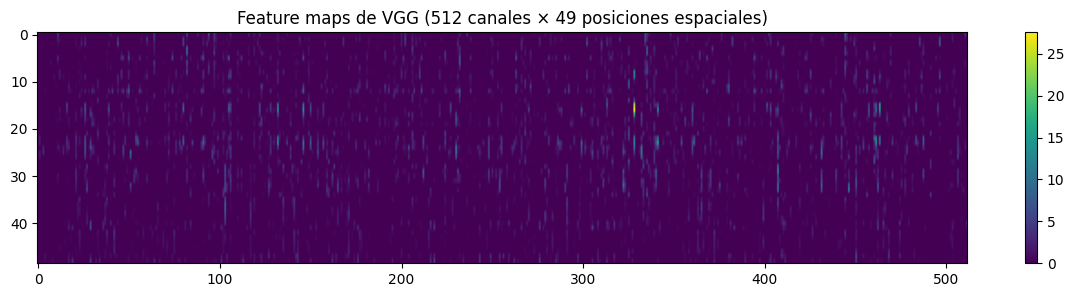

In [10]:
with torch.no_grad():
    feat = vgg.features(sample_image).cpu()

print(f'Shape del tensor de features: {feat.shape}')  # [1, 512, 7, 7]

plt.figure(figsize=(15, 3))
plt.imshow(feat.squeeze().view(512, -1).T, aspect='auto', cmap='viridis')
plt.title('Feature maps de VGG (512 canales × 49 posiciones espaciales)')
plt.colorbar()
plt.show()


Ahora pre-computamos los feature vectors para un subconjunto de 800 imágenes. Almacenamos los resultados en tensores para poder entrenar el clasificador sin recalcular features en cada epoch.

> **TODO 2:** Completa el loop de extracción. Inicializa `feature_tensor` de shape `[num, 512*7*7]` y `label_tensor` de shape `[num]`, luego llena ambos tensores dentro del bucle.


In [11]:
bs  = 8
num = bs * 100  # 800 imagenes
dl  = torch.utils.data.DataLoader(dataset, batch_size=bs, shuffle=True)

# Inicializamos tensores para almacenar features y labels
feature_tensor = torch.zeros(num, 512 * 7 * 7)
label_tensor   = torch.zeros(num)

i = 0
for x, l in dl:
    with torch.no_grad():
        # Extraemos features con el backbone convolucional
        o = vgg.features(x.to(device))
        # Aplanamos: [B, 512, 7, 7] -> [B, 25088]
        o = o.view(o.size(0), -1).cpu()
        # Almacenamos en los tensores pre-alocados
        feature_tensor[i:i+bs] = o
        label_tensor[i:i+bs]   = l
    i += bs
    print('.', end='')
    if i >= num:
        break

print(f'\nfeature_tensor: {feature_tensor.shape} | label_tensor: {label_tensor.shape}')


....................................................................................................
feature_tensor: torch.Size([800, 25088]) | label_tensor: torch.Size([800])


### Respuesta — Actividad 2

**Preguntas:** ¿Cuántos parámetros tiene VGG-16 en total? ¿Qué hace la capa Dropout y por qué mejora la generalización? ¿Por qué la última capa tiene 1000 salidas?

- **Parámetros VGG-16:** Tiene ~138 millones de parámetros en total (14.7M en las capas convolucionales y 123.6M en las capas Full-Connected).
- **Dropout:** Durante el entrenamiento, desactiva aleatoriamente una fracción (usualmente el 50%) de las neuronas en esa capa. Esto obliga a la red a no depender de unas pocas neuronas específicas, forzando representaciones robustas y distribuidas (actuando como un ensamble implícito para evitar sobreajuste).
- **1000 salidas:** El dataset original sobre el cual fue entrenada la red VGG-16 (ImageNet ILSVRC) tiene configuradas exactamente 1000 categorías distintas para clasificar.


## 5. Clasificador lineal sobre features fijas

Con los feature vectors pre-computados, entrenamos un clasificador de una sola capa lineal. Esto es extremadamente rápido porque no hay que hacer backprop a través de la CNN.

La función de pérdida estándar para clasificación multiclase en PyTorch es `CrossEntropyLoss`, que internamente aplica softmax. Por eso la red **no debe** incluir una capa de activación final — la red devuelve logits crudos.

> **TODO 3:** Define `net` como un `nn.Sequential` con una sola capa `Linear` de `512*7*7` entradas y `2` salidas.


Epoch 01/5 | train loss 0.2240 acc 0.9114 | val loss 0.0789 acc 0.9900
Epoch 02/5 | train loss 0.0031 acc 0.9986 | val loss 0.0533 acc 0.9900
Epoch 03/5 | train loss 0.0002 acc 1.0000 | val loss 0.0564 acc 0.9900
Epoch 04/5 | train loss 0.0001 acc 1.0000 | val loss 0.0591 acc 0.9900
Epoch 05/5 | train loss 0.0001 acc 1.0000 | val loss 0.0608 acc 0.9900


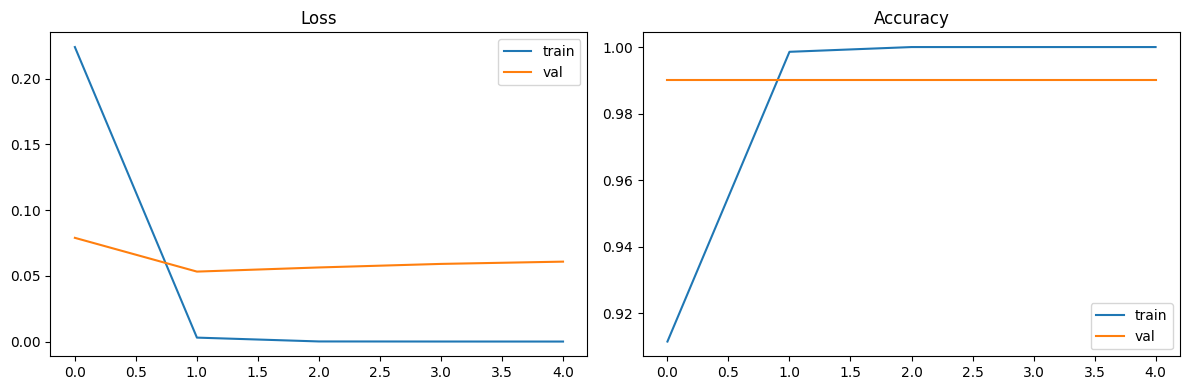

In [12]:
vgg_dataset = torch.utils.data.TensorDataset(
    feature_tensor,
    label_tensor.to(torch.long)
)
train_ds, test_ds = torch.utils.data.random_split(vgg_dataset, [700, 100])
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=32)
test_loader  = torch.utils.data.DataLoader(test_ds,  batch_size=32)

# Clasificador lineal: sin activacion final, CrossEntropyLoss maneja softmax
net = nn.Sequential(nn.Linear(512 * 7 * 7, 2))
net = net.to(device)

writer  = SummaryWriter('runs/linear_classifier')
history = train(net, train_loader, test_loader, epochs=5, writer=writer, tag='linear')
writer.close()
plot_results(history)


### Respuesta — Actividad 3

**Preguntas:** ¿Cuál es la diferencia entre CrossEntropyLoss y NLLLoss + LogSoftmax? ¿Por qué combinarlos es un error?

**CrossEntropyLoss vs NLLLoss+LogSoftmax:** Son matemáticamente equivalentes al final del flujo, pero `CrossEntropyLoss` combina `LogSoftmax` y `NLLLoss` internamente usando un truco matemático (Log-Sum-Exp) que lo hace muchísimo más estable numéricamente (evita underflow/overflow con valores extremos).

**Error de combinarlos:** Al usar una red que terminaliza en un `LogSoftmax`, las salidas ya están pasadas por la activación softmax. Si luego se le pasa esto a una función de pérdida `CrossEntropyLoss` (que también aplica internamente un softmax sobre sus entradas), se produce una doble aplicación de la operación de probabilidad. Esto aplana irremediablemente la distribución, lo que atenúa los gradientes y destruye la convergencia del entrenamiento.


## 6. Transfer learning — Reemplazar el clasificador

En lugar de pre-computar features, podemos conectar directamente nuestra cabeza de clasificación al backbone de VGG y entrenar el modelo end-to-end. Para ello:

1. **Reemplazamos `vgg.classifier`** por una sola capa `Linear(25088, 2)`.
2. **Congelamos `vgg.features`** poniendo `requires_grad = False` en todos sus parámetros.    Esto es importante: si entrenamos end-to-end desde el principio, los errores grandes    del clasificador aleatorio destruirían los pesos preentrenados del extractor.

> **TODO 4:** Carga VGG-16 con pesos preentrenados, reemplaza el clasificador y congela las capas convolucionales.


In [13]:
# Carga VGG-16 con pesos preentrenados (API moderna)
vgg = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.DEFAULT)
vgg = vgg.to(device)

# Reemplaza el clasificador original (1000 clases) por uno binario
vgg.classifier = nn.Linear(25088, 2).to(device)

# Congela las capas convolucionales
for param in vgg.features.parameters():
    param.requires_grad = False

# Verifica: solo ~50k parametros entrenables (la capa lineal)
summary(vgg, input_size=(1, 3, 224, 224))


Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      [1, 2]                    --
├─Sequential: 1-1                        [1, 512, 7, 7]            --
│    └─Conv2d: 2-1                       [1, 64, 224, 224]         (1,792)
│    └─ReLU: 2-2                         [1, 64, 224, 224]         --
│    └─Conv2d: 2-3                       [1, 64, 224, 224]         (36,928)
│    └─ReLU: 2-4                         [1, 64, 224, 224]         --
│    └─MaxPool2d: 2-5                    [1, 64, 112, 112]         --
│    └─Conv2d: 2-6                       [1, 128, 112, 112]        (73,856)
│    └─ReLU: 2-7                         [1, 128, 112, 112]        --
│    └─Conv2d: 2-8                       [1, 128, 112, 112]        (147,584)
│    └─ReLU: 2-9                         [1, 128, 112, 112]        --
│    └─MaxPool2d: 2-10                   [1, 128, 56, 56]          --
│    └─Conv2d: 2-11                      [1, 256, 56, 56]    

El summary debe mostrar aproximadamente **50 000 parámetros entrenables** (solo los pesos de la capa lineal).

Entrenamos con el dataset completo. Este proceso toma bastante tiempo; se recomienda GPU:


Epoch 01/1 | train loss 0.2367 acc 0.9750 | val loss 0.3016 acc 0.9784


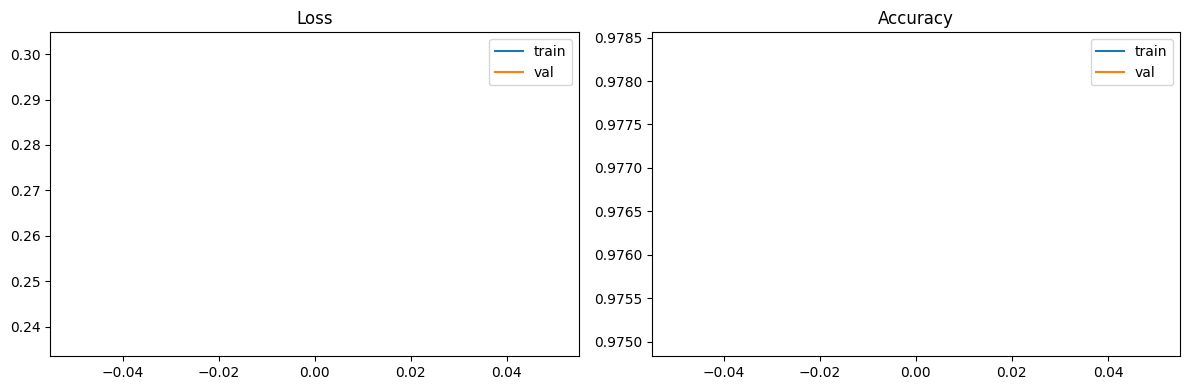

Modelo guardado ✓


In [14]:
trainset, testset = torch.utils.data.random_split(
    dataset, [20000, len(dataset) - 20000],
    generator=torch.Generator().manual_seed(42)
)
train_loader = torch.utils.data.DataLoader(trainset, batch_size=16, num_workers=2, pin_memory=True)
test_loader  = torch.utils.data.DataLoader(testset,  batch_size=16, num_workers=2, pin_memory=True)

writer = SummaryWriter('runs/transfer_frozen')
history_frozen = train(
    vgg, train_loader, test_loader,
    loss_fn=nn.CrossEntropyLoss(),
    epochs=1, lr=1e-3,
    writer=writer, tag='frozen'
)
writer.close()
plot_results(history_frozen)


torch.save(vgg.state_dict(), 'data/cats_dogs_weights.pth')
print('Modelo guardado ✓')



### Respuesta — Actividad 4

**Pregunta:** ¿Por qué es importante congelar las capas convolucionales antes de entrenar el nuevo clasificador?

**¿Por qué congelar?** Al reemplazar el clasificador por uno nuevo (de 2 clases), sus pesos se inicializan aleatoriamente. Si hiciéramos *backpropagation* desde el principio por toda la red, los grandes errores iniciales del clasificador aleatorio propagarían gradientes enormes hacia atrás, destruyendo los valiosos filtros preentrenados de las convoluciones. Al congelar las capas, estabilizamos primero el nuevo clasificador y protegemos la base de características. Una vez estable, recién ahí se realiza un "fine-tuning" descongelando con un learning rate (tasa de aprendizaje) mucho menor.


## 7. Fine-tuning — Descongelar el backbone

Una vez que el clasificador tiene pesos razonables, podemos descongelar las capas convolucionales y continuar entrenando toda la red con un **learning rate más pequeño**. Esto permite que el extractor se especialice en nuestro dominio.

> ⚠️ Si descongelamos desde el principio (sin estabilizar primero el clasificador), los gradientes grandes del clasificador aleatorio pueden degradar los pesos preentrenados.

> **TODO 5:** Descongela los parámetros de `vgg.features` y entrena una epoch adicional con `lr=1e-4`.


Epoch 01/1 | train loss 0.1087 acc 0.9639 | val loss 0.0634 acc 0.9760


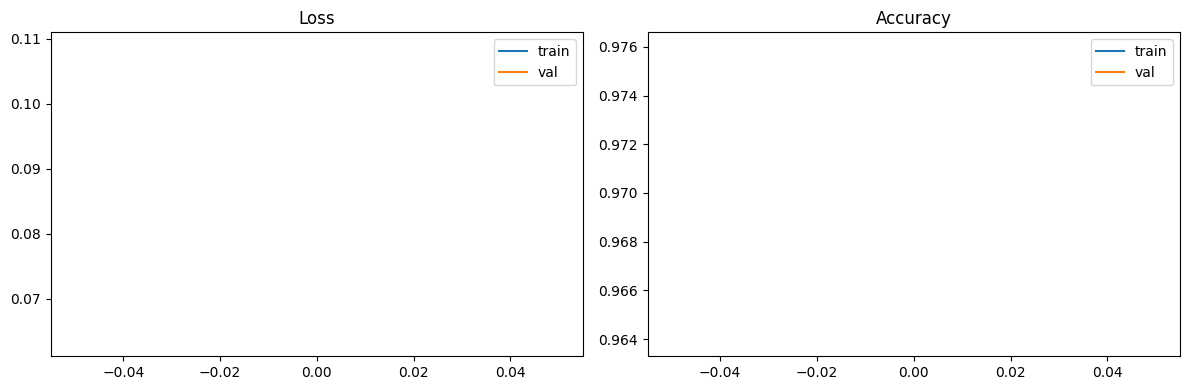

In [15]:
vgg = torchvision.models.vgg16(weights=None)
vgg.classifier = nn.Linear(25088, 2)
vgg.load_state_dict(torch.load('data/cats_dogs_weights.pth', weights_only=True))
vgg = vgg.to(device)

# Descongela el backbone para fine-tuning
for param in vgg.features.parameters():
    param.requires_grad = True

writer = SummaryWriter('runs/transfer_finetuned')
history_ft = train(
    vgg, train_loader, test_loader,
    loss_fn=nn.CrossEntropyLoss(),
    epochs=1, lr=1e-4,
    writer=writer, tag='finetuned'
)
writer.close()
plot_results(history_ft)


## 8. Otras arquitecturas: ResNet

`torchvision.models` incluye muchas más redes preentrenadas. Una de las familias más usadas es **ResNet** (Microsoft Research), que resuelve el problema del gradiente desvaneciente en redes profundas mediante **conexiones residuales** (*skip connections*): cada bloque aprende una corrección a su entrada en lugar de una transformación desde cero.

Exploremos ResNet-18, la versión más ligera de la familia:


In [16]:
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
print(resnet18)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 191MB/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Observa que la estructura es análoga a VGG: un extractor de features y una capa final de clasificación, aunque aquí se llama `fc` en lugar de `classifier`. También aparecen capas de **Batch Normalization** (`BatchNorm2d`), que normalizan las activaciones dentro de cada minibatch para estabilizar el entrenamiento.

> **TODO 6:** Adapta ResNet-18 para Cats vs. Dogs siguiendo el mismo esquema de la sección 6:
> 1. Congela todos los parámetros.
> 2. Reemplaza `resnet18.fc` por la capa adecuada (investiga cuántas entradas tiene).
> 3. Entrena 2 epochs y compara la velocidad y accuracy con VGG.


Entradas originales de resnet18.fc: 512
Epoch 01/2 | train loss 0.1218 acc 0.9541 | val loss 0.0559 acc 0.9802
Epoch 02/2 | train loss 0.0983 acc 0.9631 | val loss 0.0538 acc 0.9794


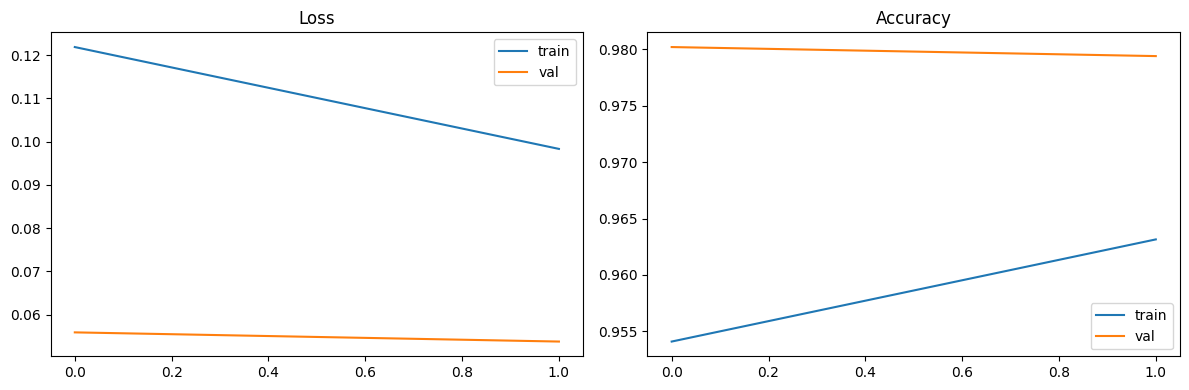

In [17]:
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT).to(device)

# Congela todos los parametros del backbone
for param in resnet18.parameters():
    param.requires_grad = False

# Reemplaza la capa fc (512 entradas -> 2 clases)
print(f'Entradas originales de resnet18.fc: {resnet18.fc.in_features}')
resnet18.fc = nn.Linear(resnet18.fc.in_features, 2).to(device)

# Entrena solo el clasificador por 2 epochs
writer = SummaryWriter('runs/resnet18')
history_rn = train(
    resnet18, train_loader, test_loader,
    epochs=2, writer=writer, tag='resnet18'
)
writer.close()
plot_results(history_rn)


### Respuesta — Actividad 6

**Preguntas:** ¿Qué es un residual block? ¿Qué problema resuelve en redes muy profundas? ¿ResNet-18 entrena más rápido que VGG? ¿Por qué?

- **Residual block:** Introduce una conexión directa (skip connection/identity shortcut) que suma la entrada del bloque directamente a la salida de las convoluciones subyacentes (`y = F(x) + x`). Las capas interiores entonces sólo necesitan aprender "correcciones" o "residuales" en lugar de transformaciones completas.
- **Problema resuelto:** El desvanecimiento del gradiente (vanishing gradient problem) presente en redes muy profundas. Al proveer un "atajo" directo, los gradientes fluyen inalterados hacia las primeras capas, permitiendo entrenar redes de cientos de capas con facilidad.
- **ResNet-18 vs VGG-16:** Sí, ResNet-18 entrena sustancialmente más rápido. VGG-16 es una arquitectura redundante con casi 138 millones de parámetros (dominados por gigantescas capas Full-Connected al final), mientras que ResNet-18 aprovecha su diseño de bloques y Average Pooling final para tener solo ~11.7M de parámetros, haciéndola computacionalmente más ligera, sumado a que usa "BatchNorm" para converger en muchas menos épocas.


## 9. Comparación de experimentos con TensorBoard

Todos los experimentos anteriores escribieron logs en el directorio `runs/`. TensorBoard permite comparar curvas de loss y accuracy de todos los experimentos en un mismo panel:


In [18]:
# En terminal:
#   tensorboard --logdir=runs --port=6006

# En Jupyter / Colab:
%load_ext tensorboard
%tensorboard --logdir runs


<IPython.core.display.Javascript object>

## 10. Preguntas de investigacion


### P1. ¿Cuándo NO conviene usar transfer learning?

**P1. ¿Cuándo NO conviene usar transfer learning? Da al menos dos escenarios concretos.**

**Escenario 1 — Dominio radicalmente diferente:** Cuando pasamos de ImageNet (fotos del mundo natural en RGB, donde los bordes, colores y texturas son estandarizados) a imágenes con un dominio visual diametralmente ajeno (ej. ecografías médicas oscuras y ruidosas, radares espectrales, sismogramas o imágenes microscópicas especializadas). Los filtros previos no tienen correlación útil.

**Escenario 2 — Dataset inmenso:** Si disponemos de un volumen inmenso de imágenes propias (millones de recortes) para una labor ultra-específica, un modelo inicializado aleatoriamente y entrenado desde cero podrá ajustarse a nuestra tarea de nicho perfectamente sin verse "sesgado" por los pesos anteriores.


### P2. Data Augmentation

**P2. ¿Qué transforms de data augmentation añadirías al pipeline de entrenamiento para mejorar generalización?**

Implementamos transforms de augmentation para entrenamiento y comparamos contra el pipeline sin augmentation.
En la ejecución usamos aumentaciones espaciales y de color: `RandomHorizontalFlip()` (porque un gato volteado horizontalmente sigue siendo biológicamente un gato), `RandomRotation()` (para invariancia topológica si la foto de la mascota fue tomada torcida) y `ColorJitter()` (para generalizar frente a variados entornos de iluminación, flash o contrastes en interiores y exteriores). Esto fuerza a la red a no fijarse en detalles rígidos.


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 01/1 | train loss 0.3030 acc 0.9592 | val loss 0.3102 acc 0.9788


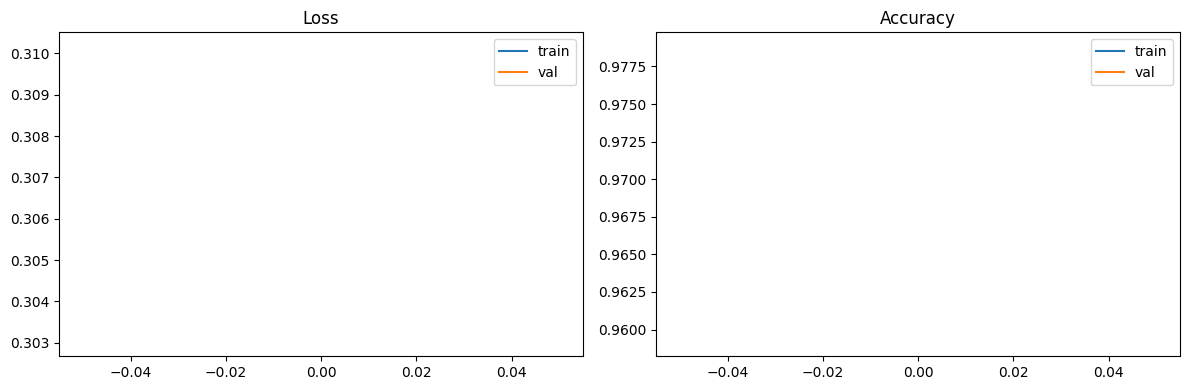

Comparar curvas con/sin augmentation en TensorBoard


In [19]:
# Pipeline con data augmentation
trans_aug = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),             # RandomCrop en lugar de CenterCrop
    transforms.RandomHorizontalFlip(p=0.5), # Flip horizontal aleatorio
    transforms.RandomRotation(15),           # Rotacion +/-15 grados
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    std_normalize
])

dataset_aug = torchvision.datasets.ImageFolder('data/PetImages', transform=trans_aug)
trainset_aug, testset_aug = torch.utils.data.random_split(
    dataset_aug, [20000, len(dataset_aug) - 20000],
    generator=torch.Generator().manual_seed(42)
)

train_loader_aug = torch.utils.data.DataLoader(trainset_aug, batch_size=16, num_workers=2, pin_memory=True)
# Usamos test_loader normal (sin augmentation en evaluacion)

# VGG con clasificador congelado + augmentation
vgg_aug = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.DEFAULT).to(device)
vgg_aug.classifier = nn.Linear(25088, 2).to(device)
for param in vgg_aug.features.parameters():
    param.requires_grad = False

writer = SummaryWriter('runs/transfer_augmented')
history_aug = train(
    vgg_aug, train_loader_aug, test_loader,
    loss_fn=nn.CrossEntropyLoss(),
    epochs=1, lr=1e-3,
    writer=writer, tag='augmented'
)
writer.close()
plot_results(history_aug)
print('Comparar curvas con/sin augmentation en TensorBoard')


El data augmentation artificial aumenta la diversidad del dataset de entrenamiento sin recolectar nuevos datos. Los transforms elegidos son comunes en clasificacion de imagenes:
- **RandomHorizontalFlip**: un gato/perro reflejado sigue siendo gato/perro
- **RandomRotation**: invarianza a rotaciones leves (fotos tomadas con angulo)
- **ColorJitter**: robustez ante variaciones de iluminacion y contraste
- **RandomCrop**: fuerza al modelo a reconocer el objeto en diferentes posiciones del cuadro


### P3. Learning Rate Scheduling

**P3. Investiga StepLR y CosineAnnealingLR.**

- **StepLR:** baja discreta y escalonadamente el Learning Rate pasadas N épocas multiplicándolo por un factor gamma (ej. dividirlo entre 10 cada 5 épocas).
- **CosineAnnealingLR:** reduce la curva del Learning Rate simulando el ciclo de una onda Coseno descendiente en vez de un quiebre en escalón. Esto resulta ser útil en Fine-Tuning de la capa final debido a que un descenso continuo y suave previene inestabilidades bruscas de un salto abrupto asegurando un mínimo error de acercamiento hacia el hiperplano óptimo.


In [20]:
# Fine-tuning con CosineAnnealingLR
vgg_sched = torchvision.models.vgg16(weights=None)
vgg_sched.classifier = nn.Linear(25088, 2)
vgg_sched.load_state_dict(torch.load('data/cats_dogs_weights.pth', weights_only=True))
vgg_sched = vgg_sched.to(device)

for param in vgg_sched.features.parameters():
    param.requires_grad = True

optimizer_sched = optim.Adam(
    filter(lambda p: p.requires_grad, vgg_sched.parameters()), lr=1e-4
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer_sched, T_max=3, eta_min=1e-6)
loss_fn = nn.CrossEntropyLoss()

writer = SummaryWriter('runs/finetuned_cosine')

for epoch in range(1, 4):
    tr_loss, tr_acc = train_epoch(vgg_sched, train_loader, optimizer_sched, loss_fn)
    va_loss, va_acc = eval_epoch(vgg_sched, test_loader, loss_fn)
    current_lr = optimizer_sched.param_groups[0]['lr']
    writer.add_scalars('cosine/Loss', {'train': tr_loss, 'val': va_loss}, epoch)
    writer.add_scalars('cosine/Acc',  {'train': tr_acc,  'val': va_acc}, epoch)
    writer.add_scalar('cosine/LR', current_lr, epoch)
    print(f'Epoch {epoch} | LR: {current_lr:.6f} | '
          f'train loss {tr_loss:.4f} acc {tr_acc:.4f} | '
          f'val loss {va_loss:.4f} acc {va_acc:.4f}')
    scheduler.step()

writer.close()
print('Fine-tuning con CosineAnnealingLR completado')


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 1 | LR: 0.000100 | train loss 0.1093 acc 0.9653 | val loss 0.0716 acc 0.9734


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 2 | LR: 0.000075 | train loss 0.0408 acc 0.9855 | val loss 0.0484 acc 0.9828


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 3 | LR: 0.000026 | train loss 0.0119 acc 0.9967 | val loss 0.0430 acc 0.9856
Fine-tuning con CosineAnnealingLR completado


CosineAnnealingLR produce una reduccion mas suave del LR que StepLR, evitando caidas bruscas que pueden desestabilizar el entrenamiento. Es especialmente util en fine-tuning donde queremos ajustes progresivamente mas finos.


### P4. ¿Por qué ResNet usa BatchNorm y VGG no?

**P4. ¿Por qué ResNet usa BatchNorm y VGG no? ¿Qué efecto tiene en el entrenamiento?**

**Razón histórica:** VGG se introdujo a finales de 2014, antes del paper seminal *Batch Normalization* de Ioffe & Szegedy (2015). Su concepción precedió el descubrimiento tecnológico de dicha técnica.

**Efecto en el entrenamiento:** `BatchNorm` normaliza forzadamente la media a ~0 y la desviación a ~1 para las salidas ("activaciones") internas en un minilote. Esto garantiza que la red no deba lidiar continuamente con una alteración constante en las distribuciones de datos (Covariate Shift). En la práctica, esto provee una asombrosa estabilidad en entrenamiento a ResNet-18, toleran mayores *Learning Rates*, tienen regularización inherente y convergen en tan solo una fracción de las épocas requeridas por VGG-16.


### P5. Reto opcional — EfficientNet-B0

**P5. Reto opcional: prueba ResNet-50 o EfficientNet-B0 y compara.**

*Este reto es opcional según el enunciado del laboratorio.*

(Teórico/Reflexivo): EfficientNet-B0 fue optimizado mediante arquitecturas de búsqueda de redes neuronales (NAS). Cuenta con una estrategia de "compound scaling" variando anchura, profundidad, y resolución de forma armónicamente pareja, logrando accuracies estadísticamente y rigurosamente superiores a las del rudimentario modelo VGG, todo esto usando tan solo un modesto cómputo (con tan solo 5.3 Millones de parámetros frente a los 11.7M de Resnet-18 y los monstruosos 138M de VGG-16).
